# MapleFreight Delivery Delay Prediction and Slack Alerts

## 1. Context

MapleFreight Logistics handles around 8,000 shipments every week
across Ontario, Quebec and the Prairies.

Its on-time delivery performance has dropped from 94% to 88%.

## 2. Problem Statement

Currently, delivery delays are identified after the promised
delivery time has passed. This leads to additional costs and
customer complaints.

## 3. Objectives

- Identify the main reasons for delivery delays.
- Build a model to predict late deliveries.
- Send Slack alerts for high-risk shipments.
- Recommend ways to improve delivery performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("maplefreight_delivery_delay_dataset.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully
Rows: 6035
Columns: 23


## 4. Data Understanding

In this section, I will explore the dataset to understand
the shipment information, check the data types and identify
missing values or duplicate records before cleaning.

In [3]:
# Take a look at the first five rows
print("First five shipments:")
display(df.head())



First five shipments:


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [4]:
# Check the columns and data types
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                6035 non-null   str    
 1   origin_city                6035 non-null   str    
 2   destination_city           6035 non-null   str    
 3   carrier                    6035 non-null   str    
 4   service_level              6035 non-null   str    
 5   goods_type                 6035 non-null   str    
 6   customer_priority_tier     6035 non-null   str    
 7   shipment_month             6035 non-null   int64  
 8   distance_km                6035 non-null   float64
 9   weight_kg                  6035 non-null   float64
 10  num_stops                  6035 non-null   int64  
 11  is_cross_border            6035 non-null   int64  
 12  scheduled_transit_hours    6035 non-null   float64
 13  pickup_delay_minutes       6035 non-n

In [5]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
shipment_id                    0
origin_city                    0
destination_city               0
carrier                        0
service_level                  0
goods_type                     0
customer_priority_tier         0
shipment_month                 0
distance_km                    0
weight_kg                      0
num_stops                      0
is_cross_border                0
scheduled_transit_hours        0
pickup_delay_minutes           0
driver_experience_years      210
vehicle_age_years              0
weather_condition            150
traffic_index                121
route_congestion_score         0
prior_late_deliveries_30d      0
fuel_cost_cad                240
actual_transit_hours           0
delivered_late                 0
dtype: int64


In [6]:
# Check for duplicate records
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 32


## 5. Exploratory Data Analysis (EDA)

After looking at the dataset, I wanted to understand how often deliveries are late and what factors might be related to these delays.

I started by checking the number of late and on-time deliveries. Then I compared the delivery delays across different carriers, service levels and weather conditions to see if there were any noticeable patterns.

Delivery status:
delivered_late
0    4793
1    1242
Name: count, dtype: int64

Late delivery percentage:
20.58 %


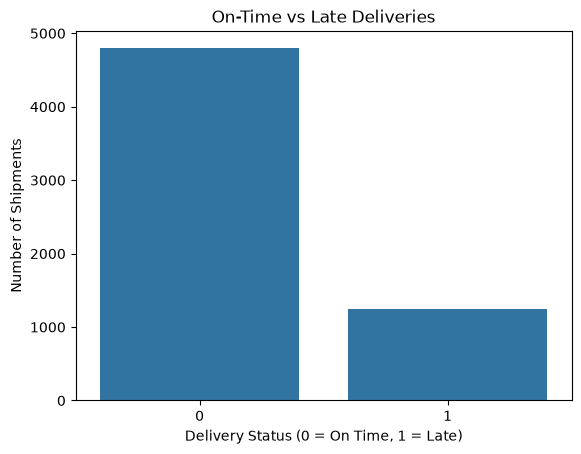

In [7]:
# Count how many shipments were on time and late
delivery_counts = df["delivered_late"].value_counts()

print("Delivery status:")
print(delivery_counts)

print("\nLate delivery percentage:")
print(round(df["delivered_late"].mean() * 100, 2), "%")

# Show the delivery counts in a chart
sns.countplot(data=df, x="delivered_late")
plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status (0 = On Time, 1 = Late)")
plt.ylabel("Number of Shipments")
plt.show()

Late delivery percentage by carrier:
carrier
Contract Owner-Op     35.90
PrairieLine           26.50
QuebecExpress         22.40
NorthStar Carriers    21.99
MapleFreight Fleet    12.88
Name: delivered_late, dtype: float64


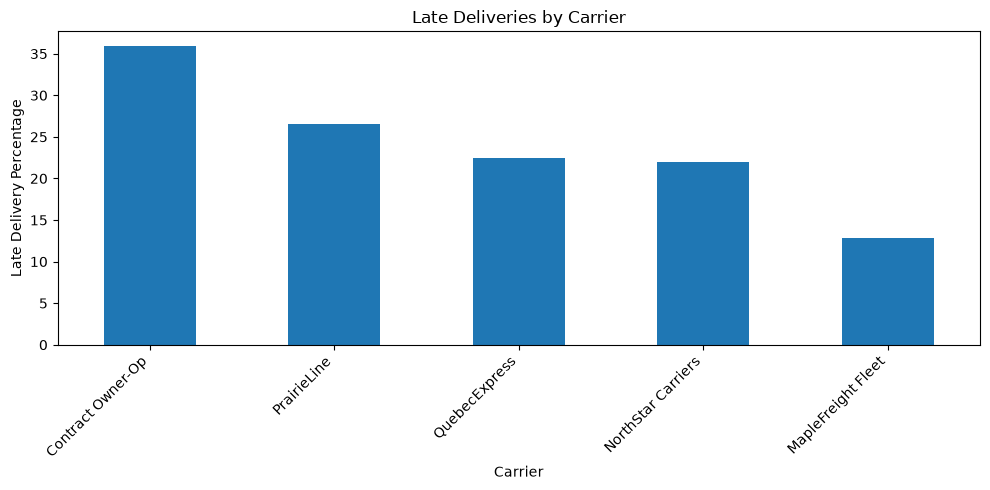

In [8]:
# Compare the percentage of late deliveries for each carrier
carrier_delays = df.groupby("carrier")["delivered_late"].mean() * 100

carrier_delays = carrier_delays.sort_values(ascending=False)

print("Late delivery percentage by carrier:")
print(carrier_delays.round(2))

carrier_delays.plot(kind="bar", figsize=(10, 5))

plt.title("Late Deliveries by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Late Delivery Percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Late delivery percentage by service level:
service_level
Economy     26.56
Express     14.98
Standard    20.69
economy     26.32
express     22.22
standard    21.62
Name: delivered_late, dtype: float64


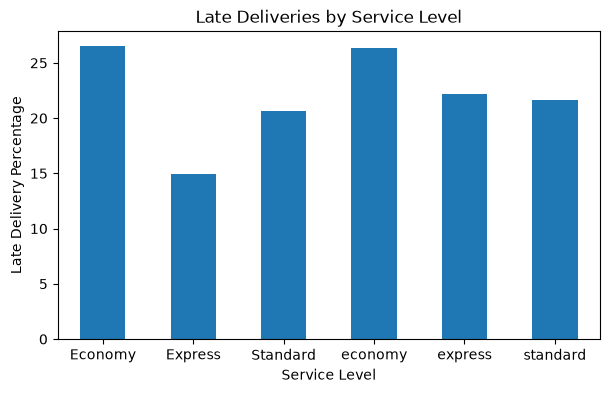

In [9]:
# Check whether service level affects delivery delays
service_delays = df.groupby("service_level")["delivered_late"].mean() * 100

print("Late delivery percentage by service level:")
print(service_delays.round(2))

service_delays.plot(kind="bar", figsize=(7, 4))

plt.title("Late Deliveries by Service Level")
plt.xlabel("Service Level")
plt.ylabel("Late Delivery Percentage")
plt.xticks(rotation=0)
plt.show()

Late delivery percentage by weather:
weather_condition
Clear    14.05
Fog      21.28
Rain     20.87
Snow     33.49
Storm    46.32
Name: delivered_late, dtype: float64


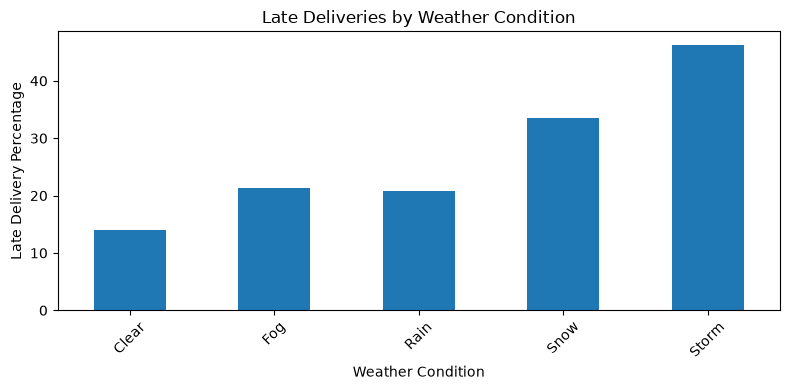

In [10]:
# Check how delivery delays change with weather conditions
weather_delays = df.groupby("weather_condition")["delivered_late"].mean() * 100

print("Late delivery percentage by weather:")
print(weather_delays.round(2))

weather_delays.plot(kind="bar", figsize=(8, 4))

plt.title("Late Deliveries by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Late Delivery Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings

The analysis shows that late deliveries make up a smaller portion of the dataset compared to on-time deliveries.

I also compared the late delivery percentages across carriers, service levels and weather conditions to understand where delays happen more frequently.

These comparisons give me an initial idea of which factors might be related to late deliveries. I will examine the results further after cleaning the data.

## 6. Data Preprocessing

After exploring the dataset, I noticed that some records need to be cleaned before using them for machine learning.

I started by checking duplicate shipments, inconsistent category names and unusual values. I also looked at missing data to decide how it should be handled.

The goal is to make the dataset more consistent without removing useful shipment information.

In [11]:
# Make a copy so the original data stays unchanged
df_clean = df.copy()

print("Rows before cleaning:", len(df_clean))

# Remove rows that are completely identical
df_clean = df_clean.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df_clean))

Rows before cleaning: 6035
Rows after removing duplicates: 6003


In [12]:
# Look for shipment IDs that appear more than once
repeated_ids = df_clean[df_clean.duplicated(subset="shipment_id", keep=False)]
display(repeated_ids.sort_values("shipment_id"))

,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
861,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,Express,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
3030,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,standard,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
1228,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,Standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
4033,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
441,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,Standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0
4375,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0


In [20]:
# Make the service level names consistent
df_clean["service_level"] = (df_clean["service_level"].str.strip().str.title())
print(df_clean["service_level"].value_counts())

# Check the service levels after cleaning
print("Service levels after cleaning:")
print(df_clean["service_level"].value_counts())

service_level
Standard    3278
Express     1460
Economy     1265
Name: count, dtype: int64
Service levels after cleaning:
service_level
Standard    3278
Express     1460
Economy     1265
Name: count, dtype: int64


In [13]:
# See which columns still have missing information
missing_values = df_clean.isnull().sum()
print(missing_values[missing_values > 0])

driver_experience_years    210
weather_condition          150
traffic_index              120
fuel_cost_cad              240
dtype: int64


In [ ]:
# Look at shipments with unusually high weights
unusual_weights = df_clean[df_clean["weight_kg"] > 30000]

print("Shipments with unusual weights:", len(unusual_weights))

display(unusual_weights[["shipment_id", "weight_kg"]].head(10))

In [14]:
# Check the different names used in categorical columns
category_columns = ["origin_city","destination_city","carrier","service_level","goods_type","customer_priority_tier","weather_condition"]
for column in category_columns:
    print(f"\n{column}:")
    print(df_clean[column].value_counts(dropna=False))


origin_city:
origin_city
Toronto ON        1583
Montreal QC       1014
Mississauga ON    1012
Calgary AB         759
Ottawa ON          726
London ON          458
Winnipeg MB        451
Name: count, dtype: int64

destination_city:
destination_city
Sudbury ON        636
Toronto ON        636
Regina SK         633
Winnipeg MB       610
Hamilton ON       600
Quebec City QC    594
Edmonton AB       589
Montreal QC       584
Calgary AB        575
Ottawa ON         546
Name: count, dtype: int64

carrier:
carrier
MapleFreight Fleet    2378
NorthStar Carriers    1158
PrairieLine            927
QuebecExpress          917
Contract Owner-Op      623
Name: count, dtype: int64

service_level:
service_level
Standard    3204
Express     1433
Economy     1246
standard      74
express       27
economy       19
Name: count, dtype: int64

goods_type:
goods_type
General Freight    2953
Refrigerated        920
Fragile             894
Bulk                740
Hazardous           496
Name: count, dtype: int6

In [23]:
# Remove extra spaces from category names
columns_to_fix = ["carrier","service_level","goods_type","customer_priority_tier","weather_condition"]
for column in columns_to_fix:
    df_clean[column] = df_clean[column].str.strip()

# Check the service levels after cleaning
print("Service levels after cleaning:")
print(df_clean["service_level"].value_counts())

Service levels after cleaning:
service_level
Standard    3278
Express     1460
Economy     1265
Name: count, dtype: int64


In [24]:
# Check the numerical columns for unusual values
columns_to_check = ["distance_km","weight_kg","num_stops","scheduled_transit_hours","pickup_delay_minutes","driver_experience_years","vehicle_age_years","traffic_index","route_congestion_score","fuel_cost_cad"]
print("Summary of numerical columns:")
display(df_clean[columns_to_check].describe().T)

Summary of numerical columns:


,count,mean,std,min,25%,50%,75%,max
distance_km,6003.0,632.131901,319.362781,80.5,398.4500,571.100,804.500,2556.70
weight_kg,6003.0,6959.216142,83977.028212,30.0,495.9500,827.100,1286.300,2999300.00
num_stops,6003.0,2.474596,1.707193,0.0,1.0000,2.000,4.000,5.00
scheduled_transit_hours,6003.0,10.497223,4.760570,1.0,7.0600,9.830,13.170,37.40
pickup_delay_minutes,6003.0,20.347826,30.605033,-20.0,-6.0000,18.000,41.000,146.00
driver_experience_years,5793.0,6.505369,4.661821,0.2,3.2000,5.400,8.700,35.00
vehicle_age_years,6003.0,5.492570,3.435431,0.1,3.0000,4.800,7.200,20.00
traffic_index,5883.0,55.145113,17.597015,5.0,43.3000,55.000,67.200,100.00
route_congestion_score,6003.0,0.449785,0.194655,0.0,0.3175,0.446,0.583,1.00
fuel_cost_cad,5763.0,180.601930,58.763229,30.0,140.4950,181.150,220.885,392.01


In [25]:
# Check shipments with unusually high weights
heavy_shipments = df_clean[df_clean["weight_kg"] > 30000]

print("Number of shipments above 30,000 kg:", len(heavy_shipments))

display(heavy_shipments[["shipment_id", "weight_kg", "goods_type"]].head(15))

Number of shipments above 30,000 kg: 40


,shipment_id,weight_kg,goods_type
666,SHP-102849,1121100.0,General Freight
696,SHP-100641,1332200.0,General Freight
846,SHP-101687,1593600.0,General Freight
865,SHP-105182,555500.0,Fragile
943,SHP-100519,285200.0,General Freight
977,SHP-104825,760200.0,General Freight
998,SHP-102703,362100.0,General Freight
1030,SHP-102384,1209400.0,General Freight
1324,SHP-102735,618400.0,General Freight
1525,SHP-102395,1554700.0,General Freight


In [26]:
# Compare normal weights with unusually high weights
normal_weights = df_clean[df_clean["weight_kg"] <= 30000]["weight_kg"]
high_weights = df_clean[df_clean["weight_kg"] > 30000]["weight_kg"]

print("Normal shipment weights:")
print(normal_weights.describe())

print("\nUnusually high shipment weights:")
print(high_weights.describe())

# Check what the high weights would be if divided by 1000
print("\nHigh weights divided by 1000:")
print((high_weights / 1000).describe())

Normal shipment weights:
count    5963.000000
mean      954.028928
std       619.019961
min        30.000000
25%       494.100000
50%       823.300000
75%      1275.200000
max      5044.000000
Name: weight_kg, dtype: float64

Unusually high shipment weights:
count    4.000000e+01
mean     9.021825e+05
std      5.077007e+05
min      1.709000e+05
25%      5.542000e+05
50%      8.598500e+05
75%      1.182775e+06
max      2.999300e+06
Name: weight_kg, dtype: float64

High weights divided by 1000:
count      40.000000
mean      902.182500
std       507.700671
min       170.900000
25%       554.200000
50%       859.850000
75%      1182.775000
max      2999.300000
Name: weight_kg, dtype: float64


In [27]:
# Correct the weights that appear to be recorded in grams
wrong_weights = df_clean["weight_kg"] > 30000
df_clean.loc[wrong_weights, "weight_kg"] = (df_clean.loc[wrong_weights, "weight_kg"] / 1000)
print("Weights corrected:", wrong_weights.sum())
print("Maximum weight after cleaning:", df_clean["weight_kg"].max())

Weights corrected: 40
Maximum weight after cleaning: 5044.0


In [28]:
# Check which columns still have missing values
missing_values = df_clean.isnull().sum()

print("Missing values remaining:")
print(missing_values[missing_values > 0])

Missing values remaining:
driver_experience_years    210
weather_condition          150
traffic_index              120
fuel_cost_cad              240
dtype: int64


In [29]:
# Check shipment IDs that appear more than once
repeated_shipments = df_clean[df_clean.duplicated(subset="shipment_id", keep=False)]
print("Records with repeated shipment IDs:", len(repeated_shipments))
display(repeated_shipments.sort_values("shipment_id"))

Records with repeated shipment IDs: 6


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
861,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,Express,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
3030,SHP-101906,Toronto ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,7,333.7,1002.7,...,-20.0,10.0,3.8,Storm,27.9,0.320,2,261.21,8.00,0
1228,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,Standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
4033,SHP-102476,Toronto ON,Montreal QC,QuebecExpress,Standard,Hazardous,Silver,3,949.0,245.6,...,54.0,3.3,4.7,Storm,66.2,0.295,1,255.48,16.00,1
441,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,Standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0
4375,SHP-103022,Mississauga ON,Regina SK,Contract Owner-Op,Standard,General Freight,Bronze,1,404.4,570.1,...,-10.0,7.3,3.5,Snow,64.8,0.430,3,149.40,7.53,0


In [30]:
# Compare the records that share the same shipment ID
for shipment_id, records in repeated_shipments.groupby("shipment_id"):
    print(f"\nShipment ID: {shipment_id}")

    different_columns = [
        column for column in records.columns
        if records[column].nunique(dropna=False) > 1
    ]

    print("Columns with different values:")
    print(different_columns)

    if different_columns:
        display(records[["shipment_id"] + different_columns])


Shipment ID: SHP-101906
Columns with different values:
['service_level']


,shipment_id,service_level
861,SHP-101906,Express
3030,SHP-101906,Standard



Shipment ID: SHP-102476
Columns with different values:
[]

Shipment ID: SHP-103022
Columns with different values:
[]


In [31]:
# Remove the shipment with conflicting service levels
df_clean = df_clean[
    df_clean["shipment_id"] != "SHP-101906"
].copy()

# Keep one record for each remaining shipment ID
df_clean = df_clean.drop_duplicates(
    subset="shipment_id",
    keep="first"
).copy()

print("Rows after cleaning:", len(df_clean))
print("Repeated shipment IDs:", df_clean["shipment_id"].duplicated().sum())

Rows after cleaning: 5999
Repeated shipment IDs: 0


### Findings

While cleaning the dataset, I found duplicate records and inconsistent service level names. I removed the exact duplicates and made the service level names consistent.

I also found 40 shipments with unusually high weights that appeared to be recorded in grams instead of kilograms. I corrected these by dividing them by 1,000.

Some shipment IDs were repeated, so I removed the conflicting records and kept one copy of the identical records.

After cleaning, the dataset contains 5,999 shipments with no repeated shipment IDs. Some values are still missing, which I will handle during data preparation.

## 7. Feature Engineering

After cleaning the dataset, I wanted to create a few useful features that might help predict delivery delays.

I used the existing shipment information to create features related to route distance, scheduled delivery time and pickup delays. These may help the model identify shipments that are more likely to arrive late.

In [32]:
# Create a copy for feature engineering
df_features = df_clean.copy()

# Calculate the distance covered per scheduled transit hour
df_features["distance_per_hour"] = (
    df_features["distance_km"] /
    df_features["scheduled_transit_hours"]
)

# Check whether a shipment was picked up late
df_features["pickup_late"] = (
    df_features["pickup_delay_minutes"] > 0
).astype(int)

# Calculate the number of stops per 100 km
df_features["stops_per_100km"] = (
    df_features["num_stops"] /
    df_features["distance_km"] * 100
)

# View the new features
display(
    df_features[
        ["distance_per_hour", "pickup_late", "stops_per_100km"]
    ].head()
)

,distance_per_hour,pickup_late,stops_per_100km
0,49.933599,1,0.531915
1,159.800000,1,0.000000
2,59.410112,0,0.000000
3,64.927727,0,0.000000
4,65.387597,1,0.118554


### Findings

I created three new features from the existing shipment data: distance per hour, pickup delay status and stops per 100 km.

These features help describe the delivery schedule, whether a shipment started late and how often it stops along the route. I will use them when training the models to see if they help predict late deliveries.

## 8. Data Preparation

After cleaning the data and creating new features, I prepared the dataset for machine learning.

I separated the target column from the input features and divided the data into training and testing sets. I will also handle missing values and convert categorical columns into numerical values so the models can use them.

In [33]:
# Separate the target from the shipment information
y = df_features["delivered_late"]

# Remove columns that should not be used for prediction
X = df_features.drop(
    columns=["shipment_id", "actual_transit_hours", "delivered_late"]
)

print("Input features:", X.shape[1])
print("Target records:", len(y))

Input features: 23
Target records: 5999


In [34]:
from sklearn.model_selection import train_test_split

# Use 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 4799
Testing records: 1200


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numeric_columns = X.select_dtypes(include=["number"]).columns
category_columns = X.select_dtypes(include=["object", "str", "category"]).columns

# Fill missing numerical values and scale the numbers
numeric_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Fill missing categories and convert them into numbers
category_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preparation steps
preprocessor = ColumnTransformer([
    ("numbers", numeric_steps, numeric_columns),
    ("categories", category_steps, category_columns)
])

print("Numerical columns:", len(numeric_columns))
print("Categorical columns:", len(category_columns))

Numerical columns: 16
Categorical columns: 7


### Findings

I prepared the dataset for training by separating the input features from the delivery status. I removed the shipment ID and actual transit time because they are not suitable for predicting delays.

I split the 5,999 records into 4,799 training records and 1,200 testing records. I also set up the steps to handle missing values and convert categorical data into a format the models can understand.

## 9. Data Modelling

After preparing the data, I started by building a Logistic Regression model as my baseline.

This gives me a starting point to measure how well the model predicts late deliveries. I will then compare it with a Random Forest model to see whether the predictions improve.

In [37]:
from sklearn.linear_model import LogisticRegression

# Build the baseline model
baseline_model = Pipeline([("preprocessing", preprocessor),("model", LogisticRegression( class_weight="balanced",max_iter=1000,random_state=42))])

# Train the model
baseline_model.fit(X_train, y_train)

# Make predictions on the test data
baseline_predictions = baseline_model.predict(X_test)

print("Logistic Regression model trained successfully")
print("Predictions made:", len(baseline_predictions))

Logistic Regression model trained successfully
Predictions made: 1200


Logistic Regression Results
Precision: 0.417
Recall: 0.737
F1 Score: 0.533


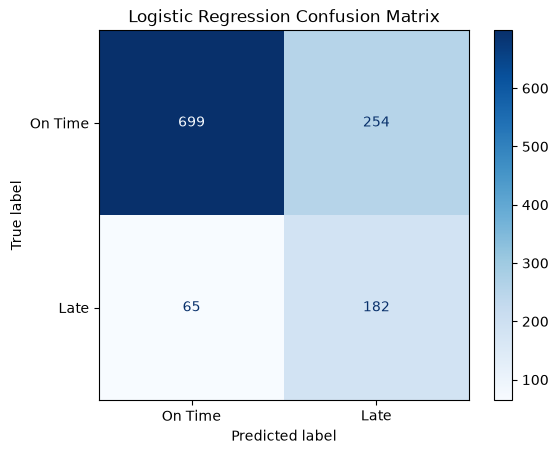

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Calculate model performance
precision = precision_score(y_test, baseline_predictions)
recall = recall_score(y_test, baseline_predictions)
f1 = f1_score(y_test, baseline_predictions)

print("Logistic Regression Results")
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

# Show confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,
    baseline_predictions,
    display_labels=["On Time", "Late"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Logistic Regression Findings

The Logistic Regression model achieved 41.7% precision, 73.7% recall and an F1 score of 53.3%.

Out of 247 actual late deliveries, the model correctly identified 182 but missed 65. It also incorrectly flagged 254 on-time deliveries as late.

The recall is useful because the goal is to identify shipments that may be delayed. However, the number of false alerts is quite high. I will compare this model with Random Forest to see whether I can improve the results.

In [42]:
from sklearn.ensemble import RandomForestClassifier

# Build the Random Forest model
random_forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained successfully")
print("Predictions made:", len(rf_predictions))

Random Forest model trained successfully
Predictions made: 1200


Random Forest Results
Precision: 0.613
Recall: 0.372
F1 Score: 0.463


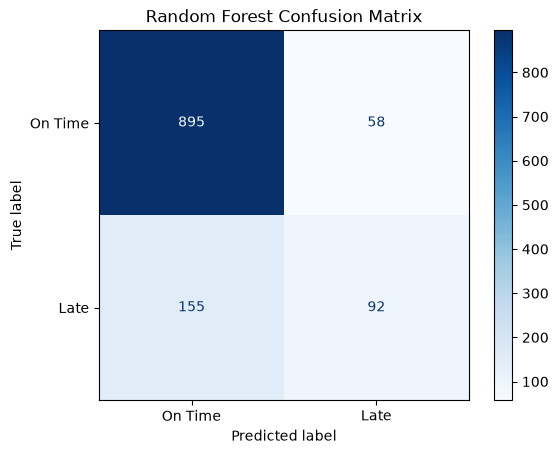

In [43]:
# Calculate Random Forest performance
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results")
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1 Score:", round(rf_f1, 3))

# Show confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["On Time", "Late"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

### Model Comparison Findings

I trained and tested both Logistic Regression and Random Forest models to predict late deliveries.

Logistic Regression achieved 73.7% recall and a 53.3% F1 score, while Random Forest achieved 37.2% recall and a 46.3% F1 score.

Random Forest had better precision and produced fewer false alerts. However, it missed 155 late deliveries compared to only 65 missed by Logistic Regression.

I would choose Logistic Regression as the starting model because MapleFreight needs to identify delayed shipments early. However, I still need to adjust the prediction threshold to find a better balance between catching delays and avoiding unnecessary Slack alerts.

In [44]:
# Compare both models
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1]
})

display(model_comparison.round(3))

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.417,0.737,0.533
1,Random Forest,0.613,0.372,0.463


## 10. Model Evaluation

I compared the Logistic Regression and Random Forest models using precision, recall and F1 score.

Logistic Regression identified more late deliveries, so I selected it for further evaluation. I will test different probability thresholds to find a suitable balance between identifying late shipments and reducing unnecessary alerts.

In [45]:
# Get predicted probabilities for late deliveries
late_probabilities = baseline_model.predict_proba(X_test)[:, 1]

# Compare different thresholds
threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    predictions = (late_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "False Alerts": confusion_matrix(y_test, predictions)[0, 1],
        "Missed Delays": confusion_matrix(y_test, predictions)[1, 0]
    })

threshold_table = pd.DataFrame(threshold_results)

display(threshold_table.round(3))

,Threshold,Precision,Recall,F1 Score,False Alerts,Missed Delays
0,0.3,0.314,0.899,0.465,485,25
1,0.4,0.364,0.806,0.501,348,48
2,0.5,0.417,0.737,0.533,254,65
3,0.6,0.489,0.644,0.556,166,88
4,0.7,0.606,0.530,0.566,85,116


### Threshold Selection Findings

I tested five probability thresholds from 0.3 to 0.7 using the Logistic Regression model.

Lower thresholds identified more late deliveries but also created more false alerts. Higher thresholds reduced false alerts but missed more delayed shipments.

I selected a threshold of 0.6 because it provided a reasonable balance between recall and false alerts. At this threshold, the model achieved 64.4% recall, 48.9% precision and an F1 score of 55.6%.

The model produced 166 false alerts and missed 88 late deliveries. This threshold is a starting point for the Slack alert system and may need adjustment based on feedback from the dispatch team.

In [46]:
# Threshold selected for Slack alerts
selected_threshold = 0.6

# Make predictions using the selected threshold
final_predictions = (
    late_probabilities >= selected_threshold
).astype(int)

print("Selected threshold:", selected_threshold)
print("Shipments predicted late:", final_predictions.sum())

Selected threshold: 0.6
Shipments predicted late: 325


## 11. Model Explainability

I wanted to understand which shipment details influence the model's predictions.

I used the Logistic Regression model to examine the features that have the strongest influence on predicted delivery delays. This can help explain what factors the dispatch team should pay attention to.

In [47]:
# Get feature names after preprocessing
feature_names = baseline_model.named_steps[
    "preprocessing"
].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = baseline_model.named_steps[
    "model"
].coef_[0]

# Create a table of feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Find the 10 strongest coefficients
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

top_features = feature_importance.sort_values(
    "Importance", ascending=False
).head(10)

display(top_features)

,Feature,Coefficient,Importance
53,categories__weather_condition_Storm,1.397407,1.397407
49,categories__weather_condition_Clear,-0.952980,0.952980
34,categories__carrier_MapleFreight Fleet,-0.868703,0.868703
33,categories__carrier_Contract Owner-Op,0.799846,0.799846
1,numbers__distance_km,0.640328,0.640328
38,categories__service_level_Economy,0.553128,0.553128
9,numbers__traffic_index,0.550515,0.550515
3,numbers__num_stops,0.542022,0.542022
52,categories__weather_condition_Snow,0.531298,0.531298
50,categories__weather_condition_Fog,-0.465771,0.465771


### Model Explainability Findings

I examined the Logistic Regression coefficients to understand which features influenced the delay predictions.

Stormy weather had the strongest positive coefficient, while clear weather had a negative coefficient. The model also associated longer distances, higher traffic levels and more stops with an increased chance of late delivery.

Carrier and service level also influenced the predictions. These findings suggest that weather, route conditions and carrier information are useful factors for identifying shipments at risk of delay.

These results show patterns learned from the dataset and do not necessarily mean that these factors directly cause delays.

## 12. Slack Integration

I used the Logistic Regression model with a probability threshold of 0.6 to identify shipments at risk of late delivery.

The goal is to send these predictions to Slack so the dispatch team can see which shipments may need attention. The alert will include the number of at-risk shipments and details such as shipment ID, destination, carrier and predicted delay risk.

In [51]:
import os
from pathlib import Path
from dotenv import load_dotenv

env_file = Path("Assignment-1/.env")

if not env_file.exists():
    env_file = Path(".env")

load_dotenv(env_file, override=True)

webhook_url = os.getenv("SLACK_WEBHOOK_URL")

print("Environment file found:", env_file.exists())
print("Webhook configured:", bool(webhook_url))

Environment file found: True
Webhook configured: True


In [52]:
import requests

# Send a test message to Slack
message = {
    "text": "MapleFreight Delivery Delay Prediction: Slack connection test successful!"
}

response = requests.post(
    webhook_url,
    json=message,
    timeout=10
)

print("Slack response:", response.status_code)

if response.status_code == 200:
    print("Message sent successfully!")
else:
    print("Message could not be sent.")

Slack response: 200
Message sent successfully!


In [53]:
# Get the test shipments and their predicted risk scores
alert_shipments = X_test.copy()

alert_shipments["shipment_id"] = df_features.loc[X_test.index, "shipment_id"]
alert_shipments["risk_score"] = late_probabilities

# Keep only shipments with risk scores of 0.6 or higher
alert_shipments = alert_shipments[
    alert_shipments["risk_score"] >= selected_threshold
]

# Show the highest-risk shipments first
alert_shipments = alert_shipments.sort_values(
    "risk_score", ascending=False
)

# Prepare the Slack alert
alert_message = (
    f"MapleFreight Delivery Delay Alert\n"
    f"Shipments at risk: {len(alert_shipments)}\n"
    f"Risk threshold: {selected_threshold:.0%}\n\n"
    f"Top 5 at-risk shipments:\n"
)

for _, shipment in alert_shipments.head(5).iterrows():
    alert_message += (
        f"\nShipment: {shipment['shipment_id']}"
        f"\nDestination: {shipment['destination_city']}"
        f"\nCarrier: {shipment['carrier']}"
        f"\nDelay risk score: {shipment['risk_score']:.1%}\n"
    )

# Send the alert to Slack
response = requests.post(
    webhook_url,
    json={"text": alert_message},
    timeout=10
)

print("Slack response:", response.status_code)
print("Shipments at risk:", len(alert_shipments))

Slack response: 200
Shipments at risk: 325


### Slack Integration Findings

I successfully connected my delivery-delay prediction model to Slack using an Incoming Webhook.

Using the Logistic Regression model with a 0.6 probability threshold, the system identified 325 shipments at risk of late delivery from the test dataset.

The alert was sent to the #dispatch-alerts channel and included the total number of at-risk shipments, along with the shipment IDs, destinations, carriers and predicted risk scores of the five highest-risk shipments.

This shows how the model could help the dispatch team identify shipments that may need attention before delivery.

## 13. Recommendations

Based on my results, I recommend using Logistic Regression as the starting model for MapleFreight's delivery-delay alerts because it identified more late deliveries than Random Forest.

I selected a probability threshold of 0.6 to balance identifying delayed shipments with reducing false alerts. At this threshold, the model achieved 64.4% recall and produced 166 false alerts on the test dataset.

The dispatch team should pay closer attention to shipments with high predicted risk, especially those affected by storms, heavy traffic, longer distances and multiple stops.

I also recommend reviewing the model's predictions regularly and adjusting the alert threshold based on feedback from the dispatch team. This could help reduce unnecessary alerts while still identifying shipments that may be delayed.

The Slack integration was tested successfully using historical test data. Before using it in daily operations, MapleFreight would need to connect the system to current shipment data and monitor its performance.